In [ ]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
# from statsmodels.tsa.stattools import adfuller
from model.config.settings import TICKERS, START_DATE, END_DATE

In [7]:
from model.src.data_pipeline import fetch_data
data_dict = {}
for ticker in TICKERS:
    df = fetch_data(ticker, START_DATE, END_DATE)
    data_dict[ticker] = df
    print(f'\n{ticker} Head:')
    print(df.head())
    print(f'{ticker} Shape: {df.shape}')

e:\Projects\Stonks\.venv\Lib\site-packages\yfinance\utils.py:567: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  splits["Stock Splits"] = splits["numerator"] / splits["denominator"]
e:\Projects\Stonks\.venv\Lib\site-packages\yfinance\utils.py


RELIANCE.NS Head:
Price            Close        High         Low        Open    Volume
Date                                                                
2018-01-01  401.864838  407.585239  400.870942  407.585239   9453202
2018-01-02  402.483215  406.193768  400.384994  403.300424   9499419
2018-01-03  404.095520  409.042914  403.322483  408.601166  13507800
2018-01-04  406.525024  407.187631  404.493061  405.575300   9008932
2018-01-05  407.828125  409.440456  406.502940  407.187633   7441284
RELIANCE.NS Shape: (1726, 5)


e:\Projects\Stonks\.venv\Lib\site-packages\yfinance\utils.py:567: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  splits["Stock Splits"] = splits["numerator"] / splits["denominator"]
e:\Projects\Stonks\.venv\Lib\site-packages\yfinance\utils.py


TCS.NS Head:
Price             Close         High          Low         Open   Volume
Date                                                                   
2018-01-01  1083.771484  1103.926270  1079.429149  1098.805639  1351760
2018-01-02  1077.872437  1093.603077  1073.366281  1089.670392  1920290
2018-01-03  1080.924194  1093.357126  1077.872318  1078.200059  1257120
2018-01-04  1088.482544  1090.489792  1081.477479  1085.573985   913082
2018-01-05  1101.632080  1105.851500  1085.573801  1085.573801  1153706
TCS.NS Shape: (1726, 5)


e:\Projects\Stonks\.venv\Lib\site-packages\yfinance\utils.py:567: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  splits["Stock Splits"] = splits["numerator"] / splits["denominator"]
e:\Projects\Stonks\.venv\Lib\site-packages\yfinance\utils.py


HDFCBANK.NS Head:
Price            Close        High         Low        Open   Volume
Date                                                               
2018-01-01  432.688995  438.813604  431.755722  436.935379  6580516
2018-01-02  436.853729  437.472029  433.633952  433.633952  4776316
2018-01-03  432.257355  438.230300  431.919026  437.472015  4531288
2018-01-04  433.948944  435.255522  432.339041  432.339041  2373776
2018-01-05  434.812256  435.850540  432.934059  434.672270  2870868
HDFCBANK.NS Shape: (1726, 5)


### Plot raw closing prices for all tickers

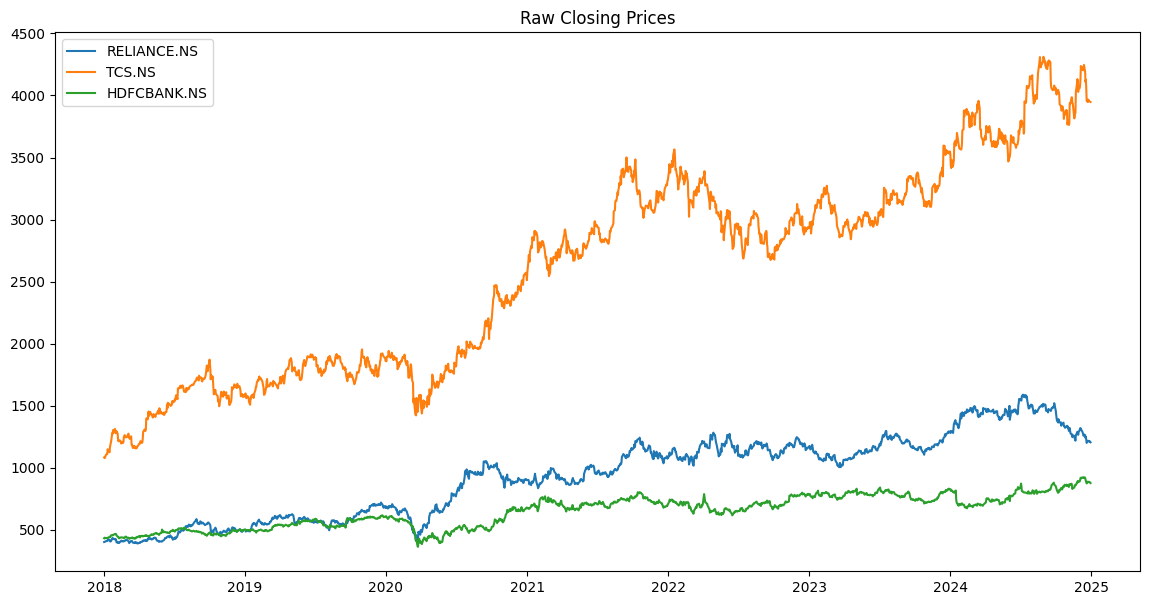

In [8]:
plt.figure(figsize=(14, 7))
for ticker, df in data_dict.items():
    plt.plot(df.index, df['Close'], label=ticker)
plt.title('Raw Closing Prices')
plt.legend()
plt.show()

### Compute and visualize technical indicators

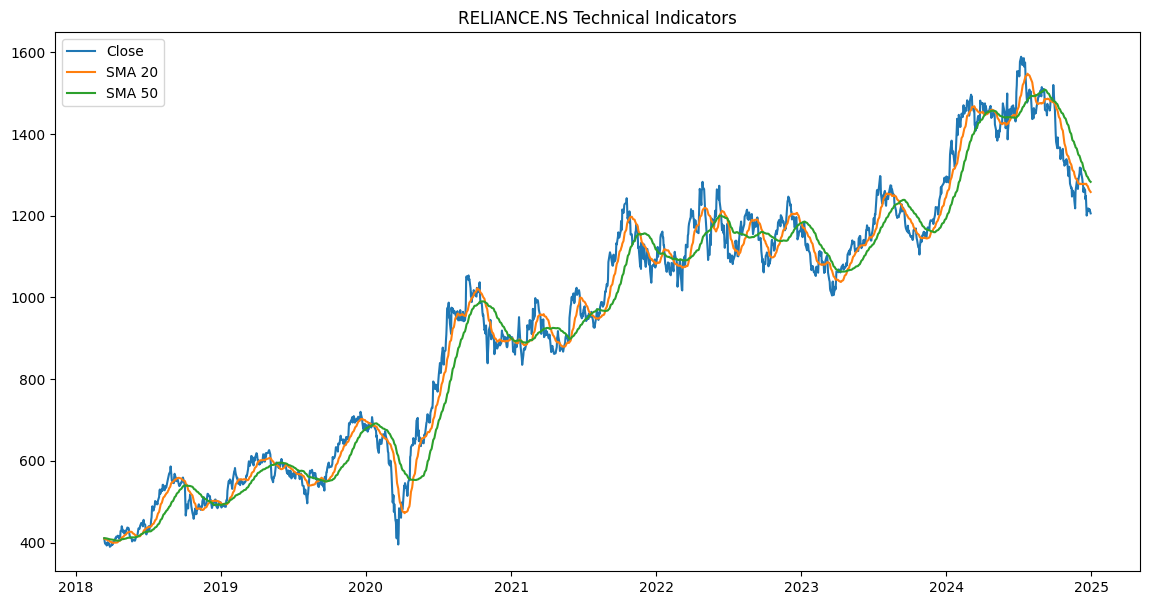

In [9]:
from model.src.data_pipeline import preprocess
processed_dict = {ticker: preprocess(df) for ticker, df in data_dict.items()}
df_rel = processed_dict['RELIANCE.NS']

plt.figure(figsize=(14, 7))
plt.plot(df_rel.index, df_rel['Close'], label='Close')
plt.plot(df_rel.index, df_rel['SMA_20'], label='SMA 20')
plt.plot(df_rel.index, df_rel['SMA_50'], label='SMA 50')
plt.title('RELIANCE.NS Technical Indicators')
plt.legend()
plt.show()

### Correlation heatmap of features

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_rel.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

NameError: name 'sns' is not defined

<Figure size 1200x800 with 0 Axes>

### Distribution plots of daily returns per ticker

In [ ]:
plt.figure(figsize=(10, 6))
for ticker, df in processed_dict.items():
    sns.kdeplot(df['Daily_Return'].dropna(), label=ticker)
plt.title('Distribution of Daily Returns')
plt.legend()
plt.show()

### Stationarity check (ADF test) on closing prices

In [ ]:
for ticker, df in data_dict.items():
    result = adfuller(df['Close'].dropna())
    print(f'{ticker} ADF Statistic: {result[0]}')
    print(f'{ticker} p-value: {result[1]}')